# Enhancing Creditworthiness Assessment beyond Traditional Credit History.

# 1.1 Business Problem
Financial institutions face losses due loss of customers as they heavily rely on credit history as the main and sometimes sole factor for determining credit-worthiness of customers. This costs them a lot of credit-worthy customers. In this project I use other factors to prove credit-worthiness of some customers instead of the unfair traditional credit history.



# 1.2 Business understanding
Traditional financial institutions have historically relied on formal credit history as the primary basis for loan approval, a practice rooted in the development of centralized credit bureaus and standardized credit scoring systems in mature financial markets. These systems were designed to provide a scalable, objective proxy for borrower risk by assuming that past borrowing behavior reliably predicts future repayment. While effective for customers with established credit records, this approach has proven increasingly limiting as banking expands to emerging markets and underserved populations, where large segments of otherwise financially responsible individuals operate outside formal credit systems and therefore lack sufficient credit footprints.

As a result, banks continue to reject approximately 25–35% of loan applications, with research and industry evidence indicating that 30–40% of these rejected applicants are in fact creditworthy when assessed using broader financial and behavioral indicators such as income stability, transaction consistency, and expense management. This over-reliance on credit history leads to an estimated 8–12% loss in potential loan volume, translating to KES 800 million–1.2 billion in unrealized lending opportunity for a mid-sized bank issuing KES 10 billion annually. Addressing this gap through enhanced data-driven credit assessment presents a clear opportunity to improve financial inclusion while capturing profitable, low-risk customers.

# 1.3 Data understanding
The dataset used in this project was obtained from Kaggle and is composed of seven relational tables containing detailed historical and behavioral credit information for loan applicants. The data represents real-world financial records typically used by traditional lending institutions to assess creditworthiness. Due to the scale and granularity of the data, the dataset captures both current application information and longitudinal credit behavior across multiple financial products. Here is the link to the dataset on kaggle :(https://www.kaggle.com/c/home-credit-default-risk/data)

## Overview of Tables
1.	Application Train (application_train)
This is the primary dataset used for model training and contains demographic, socioeconomic, and financial information for each loan applicant. It includes attributes such as income, employment history, family status, housing conditions, and loan characteristics. Importantly, this table contains the target variable indicating whether a customer defaulted on a loan. Each row represents a unique applicant identified by SK_ID_CURR.
2.	Application Test (application_test)
This table has the same structure as the training dataset but does not contain the target variable. It is used for model evaluation and prediction. It allows the trained model to assess credit risk for new applicants using learned patterns.
3.	Bureau (bureau)
This table contains historical credit records of applicants obtained from external credit bureaus. Each applicant may have multiple entries representing different loans taken in the past. Features include credit type, loan status (active or closed), credit amount, outstanding debt, and overdue amounts. This table provides insight into long-term credit behavior beyond the current loan application.
4.	Bureau Balance (bureau_balance)
This table provides monthly snapshots of an applicant’s credit status for each loan reported in the bureau table. It contains information such as days past due and loan status over time. With over one million rows, it enables temporal analysis of repayment behavior and credit stability.
5.	Previous Application (previous_application)
This table records past loan applications made by the applicant, whether approved, refused, or canceled. It includes information about loan amounts, application decisions, and contract terms. This table helps identify application behavior patterns, such as repeated rejections or frequent borrowing.
6.	Installments Payments (installments_payments)
This table captures detailed payment history for installment-based loans. It includes scheduled payment amounts, actual payments made, payment delays, and early repayments. With millions of records, it provides strong indicators of repayment discipline and financial responsibility.
7.	Credit Card Balance (credit_card_balance)
This table contains monthly credit card usage data such as balances, limits, minimum payments, and utilization. It reflects short-term financial behavior, spending discipline, and credit dependency.
8.	POS Cash Balance (POS_CASH_balance)
This table tracks point-of-sale and cash loan repayment behavior, including delinquency and contract status. It offers insight into small-loan behavior and short-term liquidity management.

### Data Characteristics
•	The dataset contains hundreds of columns across tables, including numeric, categorical, and temporal variables.
•	Several tables contain hundreds of thousands to millions of rows, reflecting one-to-many relationships with applicants.
•	Missing values are present in multiple features, often representing absence of credit history rather than data quality issues.
•	All tables are linked through unique identifiers such as SK_ID_CURR and SK_ID_BUREAU, enabling relational aggregation.




# 1.4 Data Preparation
To transform the raw multi-table credit data into a clean, consistent dataset ready for analysis, the first step will be to aggregate and merge all relational tables into a single customer-level dataset using the unique applicant identifier (SK_ID_CURR). Since most auxiliary tables contain one-to-many relationships, relevant numeric and categorical features will be summarized using statistical aggregations such as mean, sum, minimum, maximum, counts, and unique counts. This ensures that each applicant is represented by a single, comprehensive record while preserving historical credit behavior across bureau records, installments, credit cards, POS cash, and previous applications.


After merging, data cleaning and consistency checks will be applied. Missing values will be handled using context-appropriate strategies: numerical features will be imputed using median values to reduce the influence of outliers, count-based features will be filled with zeros where missing values indicate absence of credit activity, and categorical variables will be filled using forward fill, backward fill, or meaningful default categories where applicable. Data types will be validated and corrected to ensure numerical features are stored as integers or floats, and binary indicators are properly encoded as integers (0/1). Duplicate records will be checked and removed where necessary to maintain data integrity.


Finally, the dataset will be prepared for modeling by engineering ratio features, flags, and normalized metrics that better capture financial behavior, such as debt ratios, utilization rates, and repayment consistency. Outliers will be assessed using statistical methods (e.g., IQR), and feature distributions will be reviewed to ensure stability and low noise. The result will be a single, clean, and analysis-ready dataset that accurately reflects applicant behavior beyond traditional credit history, supporting fairer and more inclusive credit-worthiness assessment.


# 1.2 Business Objectives
# Main objective
To use alternative data signals to improve credit approval decisions by accurately identifying creditworthy applicants with limited or no traditional credit history.
# Specific objectives
i)	To identify important features that are neglected by legacy banks.

ii)	To handle missing values by applying appropriate statistical and logical imputation methods for numerical and categorical features.

iii)	To engineer alternative creditworthiness features such as repayment behavior, application velocity, and utilization ratios.

iv)	To encode categorical columns to make them model ready.

v)	To identify and handle outliers accordingly so that they do not affect the model.

vi)	Standardizing large numbers through log transformation so that they do not overshadow the smaller numbers


# Criteria of Success
1.	To reduce the rejection of creditworthy applicants by at least 30–40% among customers with thin or non-existent credit histories compared to a traditional credit-history-only baseline.
2.	To lower False Negatives (good borrowers incorrectly declined) by a minimum of 50%, while keeping default risk within acceptable thresholds.
3.	To demonstrate that ignored features (cash-flow stability, rent payment regularity, skill-based stability income, and first time employees) contribute significantly to credit decisions through measurable feature importance. 
4.	To increase approved loan volume by 8–12% without a corresponding increase in default rates, reflecting recovered missed lending opportunities.


# Data validation
Data validation is important in this project because it ensures that the data you are working with is accurate, consistent, and trustworthy. Decisions, models, and insights are only as good as the data behind them—if the data is wrong, the conclusions will be wrong too.

## Here are the key reasons explained clearly:

1. Prevents wrong decisions

Invalid data (wrong values, duplicates, incorrect formats) can lead to false insights. For example, a negative income value or an impossible age can distort averages, ratios, and model predictions, leading to poor business decisions.

2. Improves model performance

In projects like credit risk scoring, invalid or inconsistent data increases noise. This causes models to learn incorrect patterns, increasing false positives or false negatives. Validated data leads to more reliable and stable models.

3. Ensures consistency across datasets

When working with multiple tables (like application, bureau, installments, POS cash), validation ensures:

Keys match correctly (e.g., SK_ID_CURR)

Units and formats are consistent

Aggregations represent reality
Without validation, merges can silently fail or introduce bias.

4. Reduces bias and data leakage

Data validation helps detect:

Duplicates that overweight some customers

Future information leaking into training data

Outliers that unfairly influence predictions
This is critical in regulated domains like finance.

 # importing libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import VarianceThreshold

In [2]:
#loading the dataset

# Main application data

app_train = pd.read_csv(r"C:/Users/Microaple/Desktop/first project/application_train.csv")
app_test = pd.read_csv(r"C:/Users/Microaple/Desktop/first project/application_test.csv")

# Other relational tables
bureau = pd.read_csv(r"C:/Users/Microaple/Desktop/first project/bureau.csv")
bureau_balance = pd.read_csv(r"C:/Users/Microaple/Desktop/first project/bureau_balance.csv")
prev_app = pd.read_csv(r"C:/Users/Microaple/Desktop/first project/previous_application.csv")
pos_cash = pd.read_csv(r"C:/Users/Microaple/Desktop/first project/POS_CASH_balance.csv")
installments = pd.read_csv(r"C:/Users/Microaple/Desktop/first project/installments_payments.csv")
credit_card = pd.read_csv(r"C:/Users/Microaple/Desktop/first project/credit_card_balance.csv")
print("loaded")

loaded


## Viewing the dataset

In [3]:
# viewing the datasets
app_train.shape


(307511, 122)

In [4]:
bureau.shape

(1716428, 17)

In [5]:
credit_card.shape

(3840312, 23)

In [6]:
installments.shape

(13605401, 8)

In [7]:
installments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [8]:
bureau_balance.shape

(27299925, 3)

In [9]:
app_test.shape

(48744, 121)

In [10]:
pos_cash.shape

(10001358, 8)

# merging one to many relationship table

In [11]:
# defining aggregation function
def aggregate_one_to_many(df, group_key, prefix):
    num_cols = df.select_dtypes(include='number').columns.tolist()
    cat_cols = df.select_dtypes(include='object').columns.tolist()

    # Remove group key if present
    if group_key in num_cols:
        num_cols.remove(group_key)
    if group_key in cat_cols:
        cat_cols.remove(group_key)

    agg_dict = {}

    for col in num_cols:
        agg_dict[col] = ['mean', 'sum', 'max', 'min']

    for col in cat_cols:
        agg_dict[col] = ['nunique']

    agg = df.groupby(group_key).agg(agg_dict)

    agg.columns = [f"{prefix}_{col}_{stat}" for col, stat in agg.columns]
    agg.reset_index(inplace=True)

    return agg


In [12]:
#aggregating one to many tables
bureau_agg = aggregate_one_to_many(bureau, 'SK_ID_CURR', 'BUREAU')

bureau_balance_agg = aggregate_one_to_many(
    bureau_balance.merge(bureau[['SK_ID_BUREAU', 'SK_ID_CURR']], 
                          on='SK_ID_BUREAU', how='left'),
    'SK_ID_CURR',
    'BB'
)

prev_app_agg = aggregate_one_to_many(prev_app, 'SK_ID_CURR', 'PREV')

installments_agg = aggregate_one_to_many(installments, 'SK_ID_CURR', 'INST')

credit_card_agg = aggregate_one_to_many(credit_card, 'SK_ID_CURR', 'CC')

pos_cash_agg = aggregate_one_to_many(pos_cash, 'SK_ID_CURR', 'POS')

In [13]:
# merging the tables
final_df = app_train.copy()

final_df = (
    final_df
    .merge(bureau_agg, on='SK_ID_CURR', how='left')
    .merge(bureau_balance_agg, on='SK_ID_CURR', how='left')
    .merge(prev_app_agg, on='SK_ID_CURR', how='left')
    .merge(installments_agg, on='SK_ID_CURR', how='left')
    .merge(credit_card_agg, on='SK_ID_CURR', how='left')
    .merge(pos_cash_agg, on='SK_ID_CURR', how='left')
)

print(final_df.shape)

(307511, 420)


In [14]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 420 entries, SK_ID_CURR to POS_NAME_CONTRACT_STATUS_nunique
dtypes: float64(363), int64(41), object(16)
memory usage: 985.4+ MB


# data validation

### 1.completeness check

In [15]:
# completeness check
final_df.isnull().sum()

SK_ID_CURR                              0
TARGET                                  0
NAME_CONTRACT_TYPE                      0
CODE_GENDER                             0
FLAG_OWN_CAR                            0
                                    ...  
POS_SK_DPD_DEF_mean                 18067
POS_SK_DPD_DEF_sum                  18067
POS_SK_DPD_DEF_max                  18067
POS_SK_DPD_DEF_min                  18067
POS_NAME_CONTRACT_STATUS_nunique    18067
Length: 420, dtype: int64

###  2. uniqueness check

In [16]:
# uniqueness check
final_df.duplicated().sum()

np.int64(0)

In [17]:
final_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,POS_CNT_INSTALMENT_FUTURE_min,POS_SK_DPD_mean,POS_SK_DPD_sum,POS_SK_DPD_max,POS_SK_DPD_min,POS_SK_DPD_DEF_mean,POS_SK_DPD_DEF_sum,POS_SK_DPD_DEF_max,POS_SK_DPD_DEF_min,POS_NAME_CONTRACT_STATUS_nunique
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,289420.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.563531,4.406493,351.386075,15.697644,0.051644,0.214863,17.223497,1.468830,0.001054,2.117349
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,2.765748,60.388372,5678.136399,153.169246,4.902757,12.926305,1384.539461,30.609586,0.405600,0.563526
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,60.000000,2622.078431,267452.000000,4231.000000,882.000000,1740.554455,184970.000000,3373.000000,176.000000,5.000000


In [18]:
final_df[['DAYS_BIRTH', 'DAYS_EMPLOYED']].describe()

,DAYS_BIRTH,DAYS_EMPLOYED
count,307511.000000,307511.000000
mean,-16036.995067,63815.045904
std,4363.988632,141275.766519
min,-25229.000000,-17912.000000
25%,-19682.000000,-2760.000000
50%,-15750.000000,-1213.000000
75%,-12413.000000,-289.000000
max,-7489.000000,365243.000000


In [19]:
(final_df['DAYS_BIRTH'] > 0).value_counts()

DAYS_BIRTH
False    307511
Name: count, dtype: int64

### 3. Accuracy check

In [20]:
# Identify impossible values
# Age check (DAYS_BIRTH is negative in Home Credit)
final_df['AGE_YEARS'] = (-final_df['DAYS_BIRTH'] / 365).round(1)

# Find unrealistic ages
invalid_age = final_df[
    (final_df['AGE_YEARS'] < 18) | (final_df['AGE_YEARS'] > 100)
]

print(f"Invalid age records: {invalid_age.shape[0]}")

Invalid age records: 0


In [21]:
# Negative income
invalid_income = final_df[final_df['AMT_INCOME_TOTAL'] < 0]

# Zero or negative loan amounts
invalid_loan = final_df[final_df['AMT_CREDIT'] <= 0]

print(len(invalid_income), len(invalid_loan))

0 0


### 4.validity check

In [22]:
# validity check

final_df.dtypes

SK_ID_CURR                            int64
TARGET                                int64
NAME_CONTRACT_TYPE                   object
CODE_GENDER                          object
FLAG_OWN_CAR                         object
                                     ...   
POS_SK_DPD_DEF_sum                  float64
POS_SK_DPD_DEF_max                  float64
POS_SK_DPD_DEF_min                  float64
POS_NAME_CONTRACT_STATUS_nunique    float64
AGE_YEARS                           float64
Length: 421, dtype: object

### 5. Consistency check

In [23]:
inconsistent_income = final_df[
    (final_df['NAME_INCOME_TYPE'] == 'Unemployed') &
    (final_df['AMT_INCOME_TOTAL'] > 0)
]

print(inconsistent_income.shape[0])

22


In [24]:
final_df['EMPLOYMENT_YEARS'] = (-final_df['DAYS_EMPLOYED'] / 365)

employment_inconsistency = final_df[
    final_df['EMPLOYMENT_YEARS'] > final_df['AGE_YEARS']
]

print(employment_inconsistency.shape[0])

0


## Data Validation Report

After merging and aggregating all source tables into a single dataset (final_df), data validation was performed to ensure the data is accurate, consistent, and ready for analysis and modeling.

Completeness:
Missing values mainly resulted from left joins where applicants had no historical records. Numerical fields will be filled using median or zero (where absence implies no activity), while categorical fields will be handled using appropriate method of analysis e.g. mode or “Unknown”. Columns with excessive missing values were flagged for feature selection.

Accuracy:
Checks were conducted to identify unrealistic values such as negative incomes, invalid credit amounts, and extreme ratios. I found the data to be legit and accurate therefore ready for usage.

Consistency:
A consistency check was performed between income type and reported income. Applicants labeled as “Unemployed” but reporting positive income were flagged as logically inconsistent. These cases were reviewed to identify potential data quality issues or alternative income sources not captured by traditional employment labels.
Logical relationships across features were validated, such as alignment between credit amounts, installments, and repayment behavior. 22 inconsistensies found in two columns and will be handled by flagging them down hence creating great features for the model.

Uniqueness:
Duplicate records were checked using SK_ID_CURR to ensure one row per applicant. No duplicate customer records were found out.

Conclusion:
The dataset passed all major validation checks and is considered clean, consistent, and reliable for feature engineering and predictive modeling.

# Data Remediation

## Data cleaning

In [25]:
# handling the inconsistensy by flagging it down
final_df['INCOME_TYPE_MISMATCH'] = (
    (final_df['NAME_INCOME_TYPE'] == 'Unemployed') &
    (final_df['AMT_INCOME_TOTAL'] > 0)
).astype(int)

In [26]:
# Get numeric columns
numeric_cols = final_df.select_dtypes(include='number').columns

# Filter only columns with null values
cols_with_null = final_df[numeric_cols].isnull().sum()
cols_with_null = cols_with_null[cols_with_null > 0].index

# Compute medians for those columns
medians = final_df[cols_with_null].median()
print("Medians for columns with null values:\n", medians)
#because mean is not affected by outliers

Medians for columns with null values:
 AMT_ANNUITY                          24903.000000
AMT_GOODS_PRICE                     450000.000000
OWN_CAR_AGE                              9.000000
CNT_FAM_MEMBERS                          2.000000
EXT_SOURCE_1                             0.505998
                                        ...      
POS_SK_DPD_DEF_mean                      0.000000
POS_SK_DPD_DEF_sum                       0.000000
POS_SK_DPD_DEF_max                       0.000000
POS_SK_DPD_DEF_min                       0.000000
POS_NAME_CONTRACT_STATUS_nunique         2.000000
Length: 359, dtype: float64


In [27]:
cols_to_fill_zero = [
    'POS_SK_DPD_DEF_mean',
    'POS_SK_DPD_DEF_sum',
    'POS_SK_DPD_DEF_max',
    'POS_SK_DPD_DEF_min'
]

final_df[cols_to_fill_zero] = final_df[cols_to_fill_zero].fillna(0)
# because they show no hsitory in that column. was never present

In [28]:
final_df[cols_to_fill_zero].isnull().sum()

POS_SK_DPD_DEF_mean    0
POS_SK_DPD_DEF_sum     0
POS_SK_DPD_DEF_max     0
POS_SK_DPD_DEF_min     0
dtype: int64

In [29]:
final_df['POS_NAME_CONTRACT_STATUS_nunique'] = (
    final_df['POS_NAME_CONTRACT_STATUS_nunique'].fillna(0)
)
final_df.isnull().sum()

SK_ID_CURR                          0
TARGET                              0
NAME_CONTRACT_TYPE                  0
CODE_GENDER                         0
FLAG_OWN_CAR                        0
                                   ..
POS_SK_DPD_DEF_min                  0
POS_NAME_CONTRACT_STATUS_nunique    0
AGE_YEARS                           0
EMPLOYMENT_YEARS                    0
INCOME_TYPE_MISMATCH                0
Length: 423, dtype: int64

In [30]:
# handling the 22 inconsistensies

final_df.loc[
    (final_df['NAME_INCOME_TYPE'] == 'Unemployed') &
    (final_df['AMT_INCOME_TOTAL'] > 0),
    'NAME_INCOME_TYPE'
] = 'Other'

# i prefer this method because it 
#Keeps customer
# Realistic to African informal economies
# preserves income signal

In [31]:
final_df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [32]:
final_df.duplicated().sum()

np.int64(0)

In [33]:
final_df.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,POS_SK_DPD_max,POS_SK_DPD_min,POS_SK_DPD_DEF_mean,POS_SK_DPD_DEF_sum,POS_SK_DPD_DEF_max,POS_SK_DPD_DEF_min,POS_NAME_CONTRACT_STATUS_nunique,AGE_YEARS,EMPLOYMENT_YEARS,INCOME_TYPE_MISMATCH
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,25.9,1.745205,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,45.9,3.254795,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,52.2,0.616438,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.000000,0.0,0.0,0.0,3.0,52.1,8.326027,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.000000,0.0,0.0,0.0,3.0,54.6,8.323288,0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,1294.0,0.0,0.000000,0.0,0.0,0.0,3.0,46.4,4.350685,0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,37.7,8.575342,0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,51.6,1.230137,0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,952.0,0.0,0.346667,26.0,9.0,0.0,2.0,55.1,-1000.665753,0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,39.6,5.531507,0


# feature engineering

In [34]:
from sklearn.preprocessing import MinMaxScaler


In [35]:

# Make sure final_df is a copy

final_df = final_df.copy()


# 1. Feature Engineering

# 1. Income & Credit Capacity
final_df['CREDIT_INCOME_RATIO'] = final_df['AMT_CREDIT'] / final_df['AMT_INCOME_TOTAL']
final_df['ANNUITY_INCOME_RATIO'] = final_df['AMT_ANNUITY'] / final_df['AMT_INCOME_TOTAL']
final_df['GOODS_PRICE_CREDIT_RATIO'] = final_df['AMT_GOODS_PRICE'] / final_df['AMT_CREDIT']

# 2. Employment & Age Stability
final_df['EMPLOYED_YEARS'] = np.abs(final_df['DAYS_EMPLOYED']) / 365
final_df['AGE_YEARS'] = np.abs(final_df['DAYS_BIRTH']) / 365
final_df['EMPLOYMENT_AGE_RATIO'] = final_df['EMPLOYED_YEARS'] / final_df['AGE_YEARS']

# 3. External Source Aggregations
ext_sources = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
final_df['EXT_SOURCE_MEAN'] = final_df[ext_sources].mean(axis=1)
final_df['EXT_SOURCE_MAX'] = final_df[ext_sources].max(axis=1)
final_df['EXT_SOURCE_MIN'] = final_df[ext_sources].min(axis=1)

# 4. Credit History Presence Flags
final_df['HAS_BUREAU_HISTORY'] = (final_df['BUREAU_SK_ID_BUREAU_sum'] > 0).astype(int)
final_df['HAS_PREV_APPLICATION'] = (final_df['PREV_SK_ID_PREV_sum'] > 0).astype(int)
final_df['HAS_POS_HISTORY'] = (final_df['POS_SK_ID_PREV_sum'] > 0).astype(int)
final_df['HAS_CC_HISTORY'] = (final_df['CC_SK_ID_PREV_sum'] > 0).astype(int)

# 5. Delinquency / Risk Features
final_df['TOTAL_DPD'] = (
    final_df['BUREAU_CREDIT_DAY_OVERDUE_sum'] +
    final_df['POS_SK_DPD_sum'] +
    final_df['CC_SK_DPD_sum']
)
final_df['TOTAL_DPD_DEF'] = final_df['POS_SK_DPD_DEF_sum'] + final_df['CC_SK_DPD_DEF_sum']

# 6. Credit Card Utilization
final_df['CC_UTILIZATION'] = final_df['CC_AMT_BALANCE_mean'] / final_df['CC_AMT_CREDIT_LIMIT_ACTUAL_mean']

# 7. Installment Payment Behavior
final_df['INST_PAYMENT_RATIO'] = final_df['INST_AMT_PAYMENT_mean'] / final_df['INST_AMT_INSTALMENT_mean']

# 8. Loan Activity Intensity
final_df['TOTAL_LOAN_COUNT'] = (
    final_df['BUREAU_SK_ID_BUREAU_sum'] +
    final_df['PREV_SK_ID_PREV_sum'] +
    final_df['POS_SK_ID_PREV_sum'] +
    final_df['CC_SK_ID_PREV_sum']
)

# 9. Recent Application Behavior
final_df['RECENT_APPLICATION'] = (final_df['PREV_DAYS_DECISION_min'] > -30).astype(int)

# 10. Housing / Living Quality
final_df['LIVING_AREA_RATIO'] = final_df['LIVINGAREA_AVG'] / final_df['TOTALAREA_MODE']


# 2. Handle Missing / Infinite Values

# Replace inf/-inf with NaN
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN for sum/count features
fill_zero_cols = ['TOTAL_DPD','TOTAL_DPD_DEF','CC_UTILIZATION','TOTAL_LOAN_COUNT']
final_df[fill_zero_cols] = final_df[fill_zero_cols].fillna(0)

# Binary features (ensure integer)
binary_cols = ['HAS_BUREAU_HISTORY','HAS_PREV_APPLICATION','HAS_POS_HISTORY','HAS_CC_HISTORY','RECENT_APPLICATION']
final_df[binary_cols] = final_df[binary_cols].fillna(0).astype(int)

# Ratio / numeric features
ratio_cols = [
    'CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO','GOODS_PRICE_CREDIT_RATIO',
    'EMPLOYED_YEARS','AGE_YEARS','EMPLOYMENT_AGE_RATIO',
    'EXT_SOURCE_MEAN','EXT_SOURCE_MAX','EXT_SOURCE_MIN',
    'CC_UTILIZATION','INST_PAYMENT_RATIO','LIVING_AREA_RATIO'
]
final_df[ratio_cols] = final_df[ratio_cols].fillna(0)


# 3. Scale Ratio Features

scaler = MinMaxScaler()
final_df[ratio_cols] = scaler.fit_transform(final_df[ratio_cols])


# 4. Preview Engineered Features
engineered_features = binary_cols + ratio_cols + fill_zero_cols
print("✅ Engineered, cleaned, and scaled features preview:")
print(final_df[engineered_features].head())

✅ Engineered, cleaned, and scaled features preview:
   HAS_BUREAU_HISTORY  HAS_PREV_APPLICATION  HAS_POS_HISTORY  HAS_CC_HISTORY  \
0                   1                     1                1               0   
1                   1                     1                1               0   
2                   1                     1                1               0   
3                   0                     1                1               1   
4                   1                     1                1               0   

   RECENT_APPLICATION  CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  \
0                   0             0.023640              0.065021   
1                   0             0.056483              0.070479   
2                   0             0.023547              0.053306   
3                   0             0.027278              0.117220   
4                   0             0.049774              0.095931   

   GOODS_PRICE_CREDIT_RATIO  EMPLOYED_YEARS  AGE_YEARS  ..

In [36]:
final_df.isnull().sum()

SK_ID_CURR            0
TARGET                0
NAME_CONTRACT_TYPE    0
CODE_GENDER           0
FLAG_OWN_CAR          0
                     ..
CC_UTILIZATION        0
INST_PAYMENT_RATIO    0
TOTAL_LOAN_COUNT      0
RECENT_APPLICATION    0
LIVING_AREA_RATIO     0
Length: 442, dtype: int64

In [37]:
final_df.duplicated().sum()

np.int64(0)

  # Exploratory Data analysis

In [38]:
 final_df.shape

(307511, 442)

In [39]:
final_df.info

<bound method DataFrame.info of         SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0           100002       1         Cash loans           M            N   
1           100003       0         Cash loans           F            N   
2           100004       0    Revolving loans           M            Y   
3           100006       0         Cash loans           F            N   
4           100007       0         Cash loans           M            N   
...            ...     ...                ...         ...          ...   
307506      456251       0         Cash loans           M            N   
307507      456252       0         Cash loans           F            N   
307508      456253       0         Cash loans           F            N   
307509      456254       1         Cash loans           F            N   
307510      456255       0         Cash loans           F            N   

       FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  \
0        

In [40]:
final_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,HAS_PREV_APPLICATION,HAS_POS_HISTORY,HAS_CC_HISTORY,TOTAL_DPD,TOTAL_DPD_DEF,CC_UTILIZATION,INST_PAYMENT_RATIO,TOTAL_LOAN_COUNT,RECENT_APPLICATION,LIVING_AREA_RATIO
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,1,1,0,0.0,0.0,0.038158,0.182311,0.0,0,0.001682
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,1,1,0,0.0,0.0,0.038158,0.182311,0.0,0,0.001014
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1,1,0,0.0,0.0,0.038158,0.182311,0.0,0,0.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,1,1,1,0.0,0.0,0.038158,0.182311,0.0,0,0.000000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,1,1,0,0.0,0.0,0.038158,0.175799,0.0,0,0.000000


In [41]:
final_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,HAS_PREV_APPLICATION,HAS_POS_HISTORY,HAS_CC_HISTORY,TOTAL_DPD,TOTAL_DPD_DEF,CC_UTILIZATION,INST_PAYMENT_RATIO,TOTAL_LOAN_COUNT,RECENT_APPLICATION,LIVING_AREA_RATIO
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,3.075110e+05,307511.000000,307511.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.946493,0.941248,0.282608,158.273922,8.568279,0.079711,0.171518,4.499206e+07,0.000901,0.000754
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.225043,0.235161,0.450268,3225.199225,1036.496928,0.102644,0.046760,9.509486e+07,0.030000,0.002866
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.038158,0.172317,0.000000e+00,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.038158,0.182311,0.000000e+00,0.000000,0.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.038158,0.182311,0.000000e+00,0.000000,0.001458
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,267452.000000,224316.000000,1.000000,1.000000,9.323197e+08,1.000000,1.000000


In [42]:
final_df.isna().sum()

SK_ID_CURR            0
TARGET                0
NAME_CONTRACT_TYPE    0
CODE_GENDER           0
FLAG_OWN_CAR          0
                     ..
CC_UTILIZATION        0
INST_PAYMENT_RATIO    0
TOTAL_LOAN_COUNT      0
RECENT_APPLICATION    0
LIVING_AREA_RATIO     0
Length: 442, dtype: int64

In [43]:
final_df.duplicated().sum()

np.int64(0)

# Univariate EDA

## Distribution

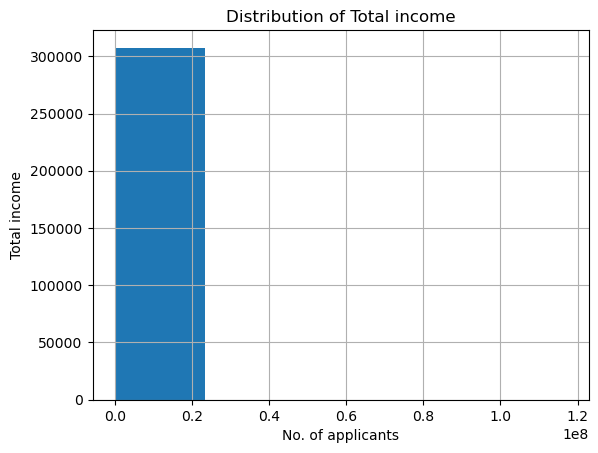

In [44]:
import matplotlib.pyplot as plt
final_df['AMT_INCOME_TOTAL'].hist(bins=5)

plt.title('Distribution of Total income')
plt.xlabel('No. of applicants')
plt.ylabel('Total income')

plt.show()

## comment
the visual shows that the vast majority of the applicants are in the lowest bracket, while a few applicants have higher incomes 

## Recommendation
use log scale for highly skewed data
check for outliers and verify that the high points are legitimate data points.

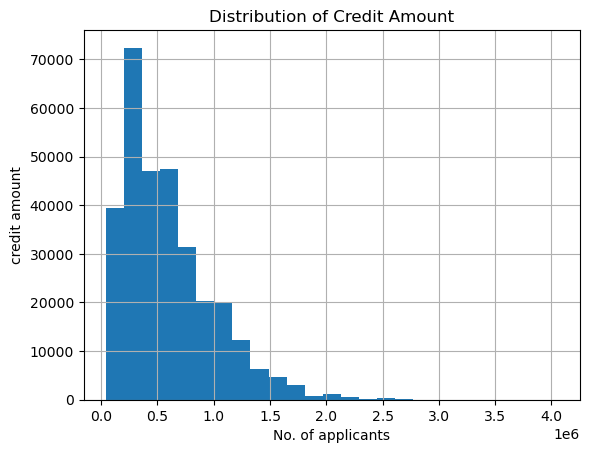

In [45]:

final_df['AMT_CREDIT'].hist(bins=25)

plt.title('Distribution of Credit Amount')
plt.xlabel('No. of applicants')
plt.ylabel('credit amount')

plt.show()

## comment
the data has a positive skewness and a few outliers.

## Recommendation
Use median to handle missing values in such dataset as it cannot be corrupted by outliers

## Checking for outliers

<Axes: >

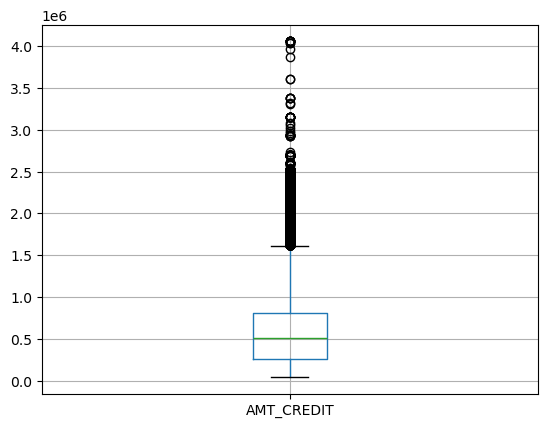

In [46]:
final_df.boxplot(column = 'AMT_CREDIT')

## comment
the data is right skewed and there is outliers in plenty

## Recommendation
Donot remove outliers and null values blindly rather use robust statistical methods e.g. median to fill null values in a data that has outliers.

<Axes: >

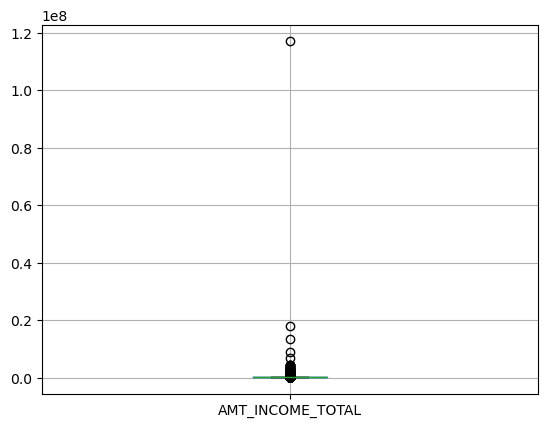

In [47]:
final_df.boxplot(column = 'AMT_INCOME_TOTAL')

## comment
there is high positive skewness and a good number of outliers.

## recommendation
you should handle outliers effectively to avoid skewing the data.

<Axes: >

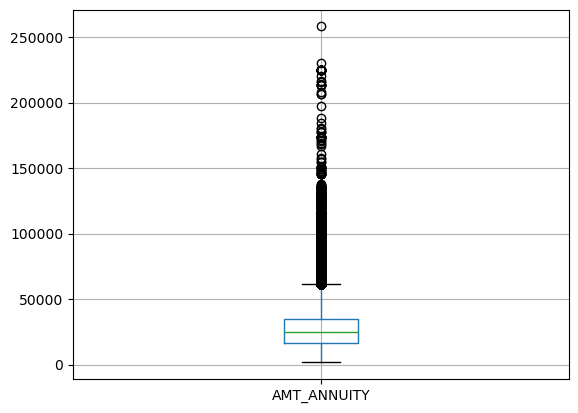

In [48]:
final_df.boxplot(column ='AMT_ANNUITY')

## comment
The data is heavily right skewed and there is extreme outliers

## recommendation
handle the outliers with the right statistical method of filling missing values e.g. median whch cannot be affected by outliers. you can also use log to deal with outliers.

<Axes: >

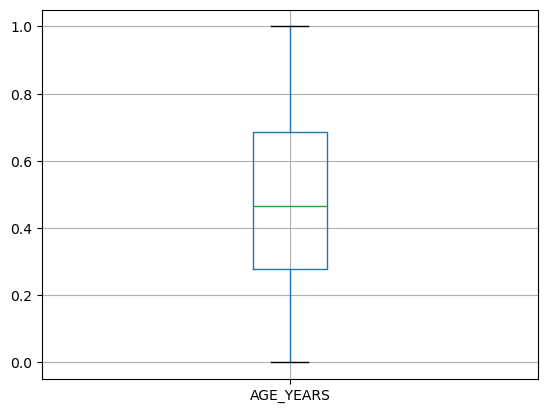

In [49]:
final_df.boxplot(column ='AGE_YEARS')

## comment
the data is evenly skewed and symmetrical.

## recommendation
there is no log transformation needed here for an obvious reason.

<Axes: >

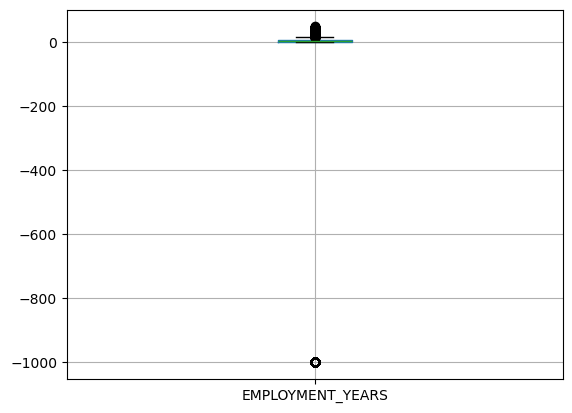

In [50]:
final_df.boxplot(column ='EMPLOYMENT_YEARS')

## comment
there is negative skewness and a mix of positive and negative ages of employment.

## recommendation
handle the signs in the ages as all should be negative 

## checking skewness 

In [51]:
final_df['EMPLOYMENT_YEARS'].skew()

np.float64(-1.6643461980685412)

In [52]:
final_df['AGE_YEARS'].skew()

np.float64(0.11567331170166081)

In [53]:
final_df['AMT_ANNUITY'].skew()

np.float64(1.5797773638612502)

In [54]:
final_df['AMT_INCOME_TOTAL'].skew()

np.float64(391.55965410418776)

In [55]:
final_df['AMT_CREDIT'].skew()

np.float64(1.2347784971349396)

# Bivariate EDA

In [56]:
# NUMERICAL VS NUMERICAL ANALYSIS
final_df[['AMT_INCOME_TOTAL', 'AMT_ANNUITY']].corr()

,AMT_INCOME_TOTAL,AMT_ANNUITY
AMT_INCOME_TOTAL,1.000000,0.191657
AMT_ANNUITY,0.191657,1.000000


## comment
there is a weak positive relationship between the two columns.AS one increases the other tend to increase slightly.
## recommendation
 Donot assume that the two columns directly affect each other.   

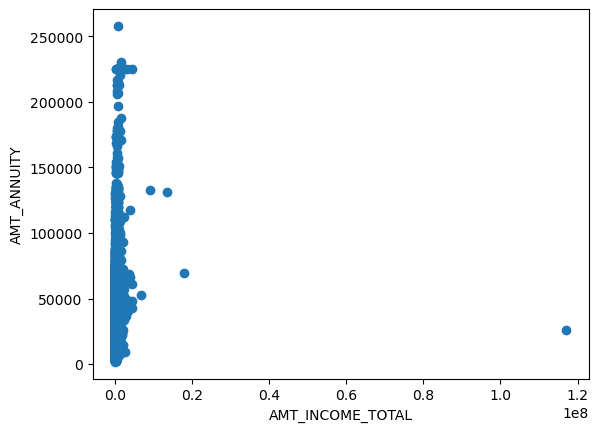

In [57]:
plt.scatter(final_df['AMT_INCOME_TOTAL'], final_df['AMT_ANNUITY'])
plt.xlabel('AMT_INCOME_TOTAL')
plt.ylabel('AMT_ANNUITY')
plt.show()

In [58]:
final_df[['AMT_INCOME_TOTAL', 'AMT_CREDIT']].corr()

,AMT_INCOME_TOTAL,AMT_CREDIT
AMT_INCOME_TOTAL,1.00000,0.15687
AMT_CREDIT,0.15687,1.00000


In [59]:
final_df[['AMT_INCOME_TOTAL', 'EMPLOYMENT_YEARS']].corr()

,AMT_INCOME_TOTAL,EMPLOYMENT_YEARS
AMT_INCOME_TOTAL,1.000000,0.064223
EMPLOYMENT_YEARS,0.064223,1.000000


In [60]:
final_df[['AMT_INCOME_TOTAL', 'AGE_YEARS']].corr()

,AMT_INCOME_TOTAL,AGE_YEARS
AMT_INCOME_TOTAL,1.000000,-0.027261
AGE_YEARS,-0.027261,1.000000


## comment 
there is a weak negative relationship between age and total income.
## recommendation
Bigger age doesnot mean higher income.

# Multivariate EDA

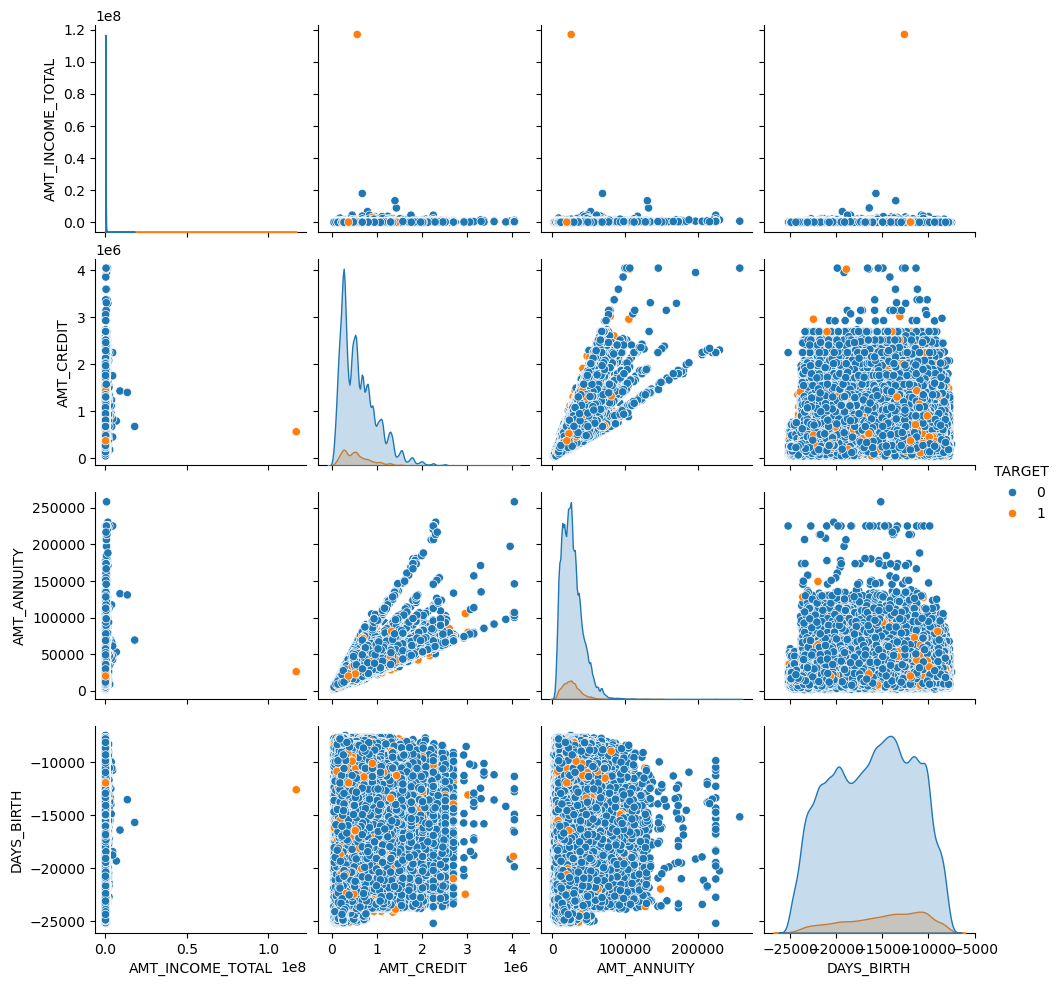

In [61]:
import seaborn as sns
selected_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'TARGET']

sns.pairplot(final_df[selected_cols], hue='TARGET',diag_kind='kde')
plt.show()

# comment
There is a positive correlation amongst all the variables selected here. Though some might be very weak. As one increases the other one increases and vice versa.

# recommendation
Keep an eye on the highly correlated variables as they are redundant and not important to the model

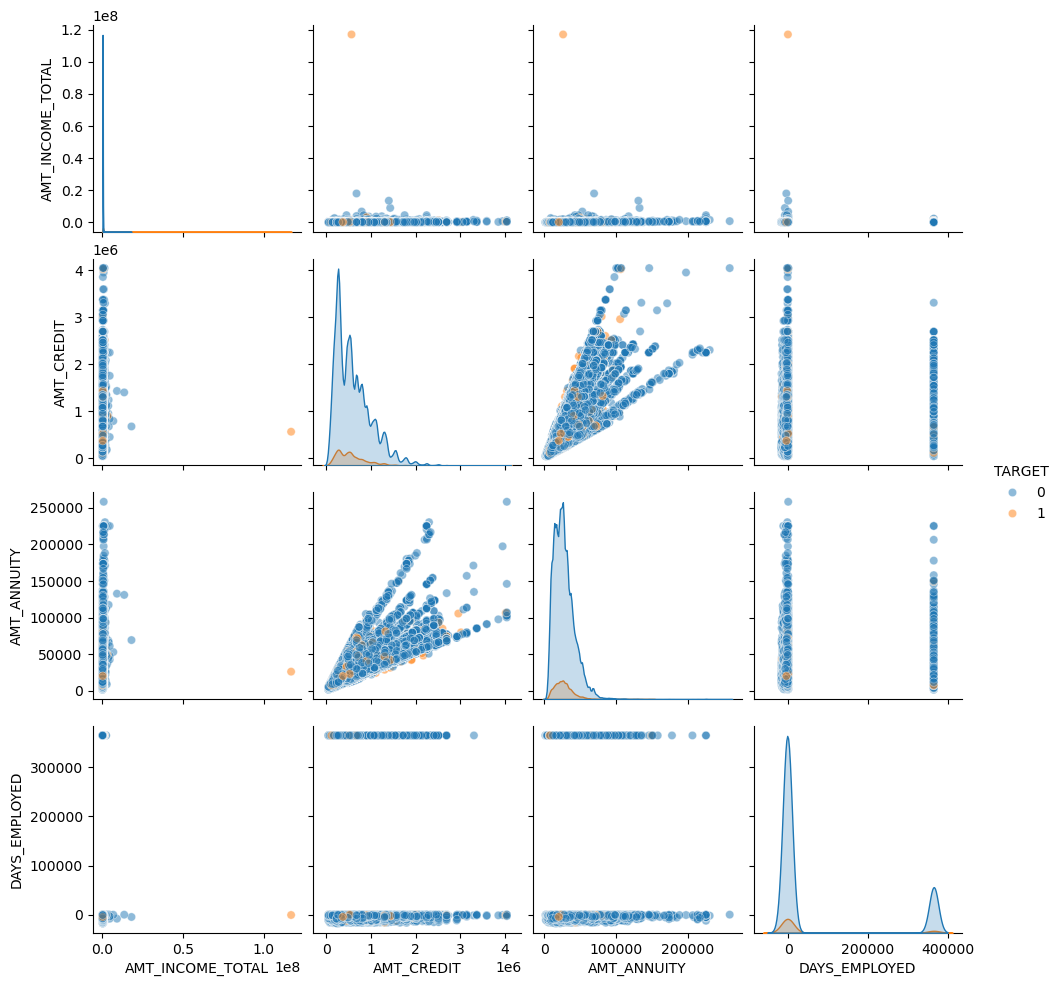

In [62]:
key_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'DAYS_EMPLOYED',
    'TARGET'
]

sns.pairplot(
    final_df[key_features],
    hue='TARGET',
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)
plt.show()

# comment
the data is positively skewed and there is a strong positive correlations between the financial metrics making them highly redundant.

# recommendation
consider techniques like feature selection and PCA to reduce the highly correlated features

In [63]:
total_apps = final_df.shape[0]
total_defaults = final_df['TARGET'].sum()
total_non_defaults = total_apps - total_defaults

# one hot encoding categorical columns

In [64]:
# 1. Identify categorical columns (excluding numeric ones)
categorical_columns = final_df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Convert binary categorical columns (flag columns) t o numerical values (Label Encoding)
binary_columns = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                  'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION', 
                  'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 
                  'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'INCOME_TYPE_MISMATCH']

# Label Encoding binary categorical columns
for col in binary_columns:
    if final_df[col].dtype == 'object':  # Check if the column is 'object' type
        final_df[col] = final_df[col].map({'Y': 1, 'N': 0, 'True': 1, 'False': 0})

# 3. Apply One-Hot Encoding for other categorical columns (excluding binary columns)
# These are the remaining non-binary categorical columns
categorical_columns = list(set(categorical_columns) - set(binary_columns))

# Perform One-Hot Encoding for non-binary categorical columns
final_df_encoded = pd.get_dummies(final_df, columns=categorical_columns, drop_first=True)

# 4. Check the data types after encoding
print("Data types after encoding:\n", final_df_encoded.dtypes)

# 5. Separate `TARGET` column (this is the column you want to predict)
X = final_df_encoded.drop(columns=['TARGET', 'SK_ID_CURR'])  # Remove target and identifier from features
y = final_df_encoded['TARGET']  # Target column for prediction

# 6. Now X and y are ready for model training
print(X.shape, y.shape)  

Data types after encoding:
 SK_ID_CURR                              int64
TARGET                                  int64
FLAG_OWN_CAR                            int64
FLAG_OWN_REALTY                         int64
CNT_CHILDREN                            int64
                                        ...  
OCCUPATION_TYPE_Realty agents            bool
OCCUPATION_TYPE_Sales staff              bool
OCCUPATION_TYPE_Secretaries              bool
OCCUPATION_TYPE_Security staff           bool
OCCUPATION_TYPE_Waiters/barmen staff     bool
Length: 550, dtype: object
(307511, 548) (307511,)


# Feature elimination using RFE

In [66]:
# installing lightgbm

!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 2.0 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.3 MB/s  0:00:01


In [67]:
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import lightgbm as lgb
# Assuming 'final_df' is your DataFrame
# Separate features (X) and target (y)
X = final_df_encoded.drop(columns=['TARGET', 'SK_ID_CURR'])  # Exclude target and identifier
y = final_df_encoded['TARGET']

# 1. Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Initialize the model (LightGBM or RandomForest, for feature importance)
model = lgb.LGBMClassifier(random_state=42)

# 3. Apply Recursive Feature Elimination (RFE)
# We use RFE with a base estimator (model) 
rfe = RFE(estimator=model, n_features_to_select=50, step=5)  # Keep top 20 features
rfe.fit(X_train, y_train)

# 4. Get the ranking of features (1 indicates the most important feature)
selected_features = X.columns[rfe.support_]

# 5. Output the ranking and selected features
print("Selected Features:", selected_features)
print("Feature Ranking:", rfe.ranking_)

# 6. Align the selected features for both training and test sets
# Ensure the same features are used in both the training and test sets
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# 7. Train the model with the selected features only

model.fit(X_train_selected, y_train)

# 8. Evaluate the model
y_pred = model.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy with Selected Features: {accuracy:.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.546642 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 71979
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 536
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.858336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 71826
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 531
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[Lig

# Checking the ROC AUC score

# metrics evaluation

In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
# predicting class labels
y_pred = model.predict(X_test_selected)

# If you're predicting probabilities (for ROC-AUC calculation)
y_prob = model.predict_proba(X_test_selected)[:, 1]  # For binary classification, get the probability of class 1

# Calculate precision, recall, f1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate ROC-AUC score (use predicted probabilities, not labels)
roc_auc = roc_auc_score(y_test, y_prob)

# Print the metrics
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Precision: 0.5635179153094463
Recall: 0.03484390735146022
F1-score: 0.06562974203338391
ROC-AUC: 0.7768768517476521


  # checking out default and non default

In [69]:
# Count the number of defaults (class 1) and non-defaults (class 0)
defaults = (y_test == 1).sum()  # Defaults (1 represents default)
non_defaults = (y_test == 0).sum()  # Non-defaults (0 represents non-default)

# Print the results
print(f"Number of Defaults (1): {defaults}")
print(f"Number of Non-Defaults (0): {non_defaults}")

Number of Defaults (1): 4965
Number of Non-Defaults (0): 56538


In [70]:
# calculating default rate
defaults = (y_test == 1).sum()  # Defaults (1 represents default)
# Total number of instances in the dataset
total_instances = len(y_test)
# Default rate in percentage
default_rate = (defaults / total_instances) * 100

print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 8.07%


In [71]:
# Number of non-defaults (TARGET == 0)
num_non_defaults = (y_test == 0).sum()

# Total number of instances in the dataset
total_instances = len(y_test)

# Non-default rate in percentage
non_default_rate = (num_non_defaults / total_instances) * 100

print(f"Non-Default Rate: {non_default_rate:.2f}%")

Non-Default Rate: 91.93%


# Convert your variables into DataFrame columns

In [72]:
df = pd.DataFrame({
    "Recall": [recall],
    "Precision": [precision],
    "F1 Score": [f1],
    "ROC AUC": [roc_auc],  
    "Default Rate": [default_rate],
    "Non Default Rate": [non_default_rate],
    "Total Applications": [total_apps],
    "Defaults": [defaults],
    "Non Defaults": [non_defaults]
})

# saving the dataset

In [73]:
# Save the DataFrame as a CSV file
final_df_encoded.to_csv('final_dataset.csv', index=False) 


In [74]:
import joblib

# Example: LightGBM model
joblib.dump(model, "loan_default_model.pkl")

['loan_default_model.pkl']